# importing libraries 

In [104]:
import pandas as pd
import os
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report

# importing data

In [105]:
print(os.getcwd())
filepath = os.path.join(os.path.dirname(os.getcwd()), 'data/dataset/processed/go_emotion_dutch.csv')

c:\Users\koenm\Documents\repositorys\year_2\fae2-nlpr-group-group-4-1\fae2-nlpr-group-group-4-1\nlp_cia\task 6


In [106]:
filepath_2 = os.path.join(os.path.dirname(os.getcwd()), "data/group_4_url_1_transcript.csv")
df_test = pd.read_csv(filepath_2)
df_test = df_test.sample(n=len(df_test))

In [107]:
import pandas as pd

splits = {'train': 'simplified/train-00000-of-00001.parquet', 'validation': 'simplified/validation-00000-of-00001.parquet', 'test': 'simplified/test-00000-of-00001.parquet'}
df = pd.read_parquet("hf://datasets/google-research-datasets/go_emotions/" + splits["train"])

In [108]:
df.head()

,text,labels,id
0,My favourite food is anything I didn't have to...,[27],eebbqej
1,"Now if he does off himself, everyone will thin...",[27],ed00q6i
2,WHY THE FUCK IS BAYLESS ISOING,[2],eezlygj
3,To make her feel threatened,[14],ed7ypvh
4,Dirty Southern Wankers,[3],ed0bdzj


In [109]:
import pandas as pd

# Read the data
splits = {'train': 'simplified/train-00000-of-00001.parquet', 'validation': 'simplified/validation-00000-of-00001.parquet', 'test': 'simplified/test-00000-of-00001.parquet'}
df = pd.read_parquet("hf://datasets/google-research-datasets/go_emotions/" + splits["train"])

# Map numbers to our 7 emotions
emotion_mapping = {
    0: 'happiness',  # admiration
    1: 'happiness',  # amusement
    2: 'anger',      # anger
    3: 'anger',      # annoyance
    4: 'happiness',  # approval
    5: 'happiness',  # caring
    6: 'surprise',   # confusion
    7: 'neutral',    # curiosity
    8: 'neutral',    # desire
    9: 'sadness',    # disappointment
    10: 'anger',     # disapproval
    11: 'disgust',   # disgust
    12: 'sadness',   # embarrassment
    13: 'happiness', # excitement
    14: 'fear',      # fear
    15: 'happiness', # gratitude
    16: 'sadness',   # grief
    17: 'happiness', # joy
    18: 'happiness', # love
    19: 'fear',      # nervousness
    20: 'happiness', # optimism
    21: 'happiness', # pride
    22: 'surprise',  # realization
    23: 'happiness', # relief
    24: 'sadness',   # remorse
    25: 'sadness',   # sadness
    26: 'surprise',  # surprise
    27: 'neutral'    # neutral
}

# Map the labels column
def map_labels(labels_list):
    if len(labels_list) == 0:
        return 'neutral'
    return emotion_mapping[labels_list[0]]

df['emotion'] = df['labels'].apply(map_labels)

# Keep only text and emotion
df = df[['text', 'emotion']]

print(df['emotion'].value_counts())

emotion
happiness    16405
neutral      15138
anger         5336
surprise      2717
sadness       2619
fear           615
disgust        580
Name: count, dtype: int64


In [110]:
df_train = df

In [111]:
df_train.head()

,text,emotion
0,My favourite food is anything I didn't have to...,neutral
1,"Now if he does off himself, everyone will thin...",neutral
2,WHY THE FUCK IS BAYLESS ISOING,anger
3,To make her feel threatened,fear
4,Dirty Southern Wankers,anger


In [112]:
filepath_2 = os.path.join(os.path.dirname(os.getcwd()), "data/group_4_url_1_transcript.csv")
df_test = pd.read_csv(filepath_2)
df_test = df_test.sample(n=len(df_test))

# training model

In [113]:
# Train on df_train
vectorizer = TfidfVectorizer(
    max_features=7000,        # Keep top N most frequent words
    ngram_range=(1, 2),       # (1,1) = unigrams, (1,2) = uni+bigrams
    min_df=2,                 # Ignore words appearing in < 2 documents
    max_df=0.95,              # Ignore words appearing in > 95% of docs
    sublinear_tf=True,        # Apply log scaling to term frequency
    use_idf=True,             # Use inverse document frequency
    norm='l2'                 # Normalize vectors to unit length
)
X_train_tfidf = vectorizer.fit_transform(df_train['text'])

model = MultinomialNB(alpha=1.0,                # Smoothing parameter (higher = more smoothing)
                      
                      fit_prior=True).fit(X_train_tfidf, df_train['emotion'])


# Test on df_test
X_test_tfidf = vectorizer.transform(df_test['Translation'])
predictions = model.predict(X_test_tfidf)

# Calculate metrics
accuracy = accuracy_score(df_test['Emotion_core'], predictions)
precision = precision_score(df_test['Emotion_core'], predictions, average='weighted')
recall = recall_score(df_test['Emotion_core'], predictions, average='weighted')
f1 = f1_score(df_test['Emotion_core'], predictions, average='weighted')

print(f"Accuracy:  {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall:    {recall:.3f}")
print(f"F1-score:  {f1:.3f}")
print(classification_report(df_test['Emotion_core'], predictions))

Accuracy:  0.499
Precision: 0.479
Recall:    0.499
F1-score:  0.426
              precision    recall  f1-score   support

       anger       0.43      0.08      0.14        37
     disgust       0.00      0.00      0.00        17
        fear       0.00      0.00      0.00        56
   happiness       0.34      0.60      0.44       198
     neutral       0.58      0.73      0.65       546
     sadness       1.00      0.02      0.04       104
    surprise       0.00      0.00      0.00        92

    accuracy                           0.50      1050
   macro avg       0.34      0.20      0.18      1050
weighted avg       0.48      0.50      0.43      1050



c:\Users\koenm\miniconda3\envs\p12dupa\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\koenm\miniconda3\envs\p12dupa\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\koenm\miniconda3\envs\p12dupa\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", res

# hyper parameter tuning

In [114]:
# Try different alpha values
for alpha in [0.1, 0.5, 1.0, 2.0]:
    model = MultinomialNB(alpha=alpha).fit(X_train_tfidf, df_train['emotion'])
    predictions = model.predict(X_test_tfidf)
    acc = accuracy_score(df_test['Emotion_core'], predictions)
    print(f"Alpha={alpha}: {acc:.3f}")

Alpha=0.1: 0.502
Alpha=0.5: 0.499
Alpha=1.0: 0.499
Alpha=2.0: 0.495


# error analysis

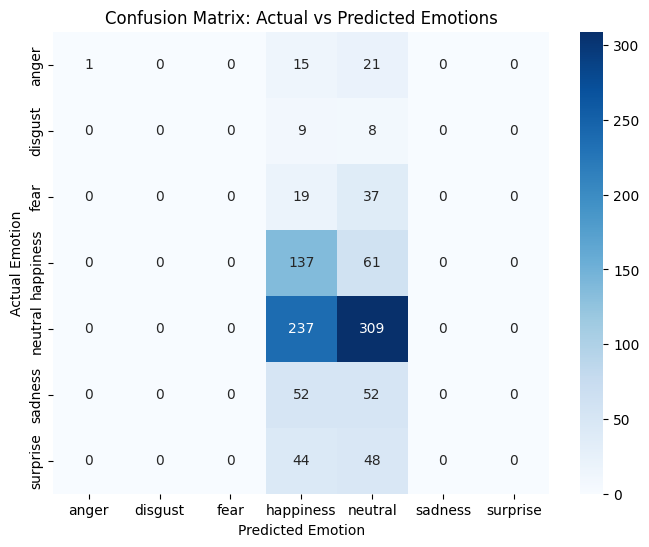


Prediction Distribution:
neutral      536
happiness    513
anger          1
Name: count, dtype: int64

Actual Distribution:
Emotion_core
neutral      546
happiness    198
sadness      104
surprise      92
fear          56
anger         37
disgust       17
Name: count, dtype: int64


In [115]:
# Train on df_train
vectorizer = TfidfVectorizer()
X_train_tfidf = vectorizer.fit_transform(df_train['text'])
model = MultinomialNB().fit(X_train_tfidf, df_train['emotion'])

# Test on df_test
X_test_tfidf = vectorizer.transform(df_test['Translation'])
predictions = model.predict(X_test_tfidf)

# Create confusion matrix
cm = confusion_matrix(df_test['Emotion_core'], predictions)
emotions = sorted(df_test['Emotion_core'].unique())


# Visualize
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=emotions, yticklabels=emotions)
plt.title('Confusion Matrix: Actual vs Predicted Emotions')
plt.ylabel('Actual Emotion')
plt.xlabel('Predicted Emotion')
plt.show()

# Show prediction distribution
print("\nPrediction Distribution:")
print(pd.Series(predictions).value_counts())
print("\nActual Distribution:")
print(df_test['Emotion_core'].value_counts())

In [116]:
# Train on df_train
vectorizer = TfidfVectorizer(
    max_features=7000,        # Keep top N most frequent words
    ngram_range=(1, 2),       # (1,1) = unigrams, (1,2) = uni+bigrams
    min_df=2,                 # Ignore words appearing in < 2 documents
    max_df=0.95,              # Ignore words appearing in > 95% of docs
    sublinear_tf=True,        # Apply log scaling to term frequency
    use_idf=True,             # Use inverse document frequency
    norm='l2'                 # Normalize vectors to unit length
)
X_train_tfidf = vectorizer.fit_transform(df_train['text'])
model = LinearSVC(class_weight='balanced', max_iter=2000).fit(X_train_tfidf, df_train['emotion'])

# Test on df_test
X_test_tfidf = vectorizer.transform(df_test['Translation'])
predictions = model.predict(X_test_tfidf)

# Calculate metrics
accuracy = accuracy_score(df_test['Emotion_core'], predictions)
precision = precision_score(df_test['Emotion_core'], predictions, average='weighted')
recall = recall_score(df_test['Emotion_core'], predictions, average='weighted')
f1 = f1_score(df_test['Emotion_core'], predictions, average='weighted')

print(f"Accuracy:  {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall:    {recall:.3f}")
print(f"F1-score:  {f1:.3f}")

Accuracy:  0.530
Precision: 0.509
Recall:    0.530
F1-score:  0.504


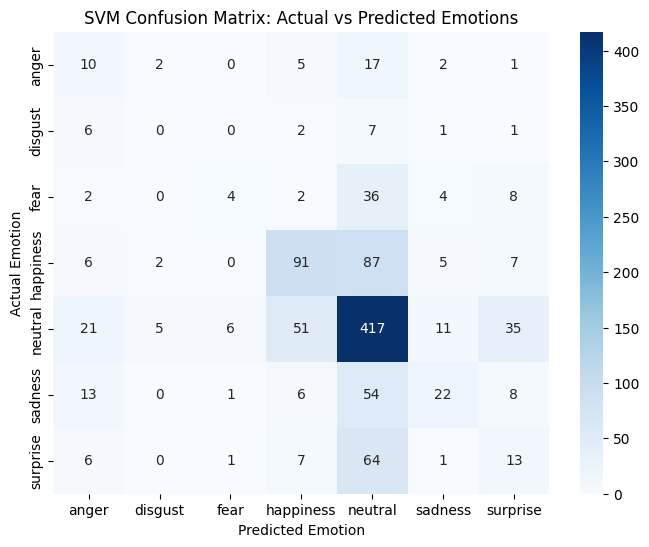


Prediction Distribution:
neutral      682
happiness    164
surprise      73
anger         64
sadness       46
fear          12
disgust        9
Name: count, dtype: int64

Actual Distribution:
Emotion_core
neutral      546
happiness    198
sadness      104
surprise      92
fear          56
anger         37
disgust       17
Name: count, dtype: int64


In [117]:
# Create confusion matrix
cm = confusion_matrix(df_test['Emotion_core'], predictions)
emotions = sorted(df_test['Emotion_core'].unique())

# Visualize
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=emotions, yticklabels=emotions)
plt.title('SVM Confusion Matrix: Actual vs Predicted Emotions')
plt.ylabel('Actual Emotion')
plt.xlabel('Predicted Emotion')
plt.show()

# Show prediction distribution
print("\nPrediction Distribution:")
print(pd.Series(predictions).value_counts())
print("\nActual Distribution:")
print(df_test['Emotion_core'].value_counts())